# EV - Battery - RUL - Prediction.

In [15]:
import os
import glob
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader

# -- 1. Data Processing with Normalization
This section transforms raw sensor readings into a format the model can actually digest.Dynamic Key Access: By using keys = [k for k in mat.keys() if not k.startswith('__')], you solve the issue where different files used different root keys (e.g., 'B0005' vs 'B0006'), preventing the previous KeyError.Signal Resampling: Battery discharge cycles vary in duration. Resampling every signal to 200 points ensures every input into the CNN has a fixed shape, which is required for the 1D Convolutional layers.RUL Definition: You define "End of Life" as 70% of initial capacity. This provides a clear, linear target for the model to learn.Dual-Level Scaling:Input Scaling: MinMaxScaler brings Voltage, Current, and Temperature into a $[0, 1]$ range.Target Normalization: Dividing the RUL by max_rul is the most critical fix for your "flat line" issue. It keeps gradients small and manageable for the LSTM during the early stages of training.

In [16]:
# --- 1. Data Processing with Normalization ---
def load_battery_mat(file_path):
    mat = loadmat(file_path)
    keys = [k for k in mat.keys() if not k.startswith('__')]
    battery_id = keys[0]
    battery_data = mat[battery_id][0, 0]['cycle'][0]
    
    cycles = []
    for entry in battery_data:
        if entry["type"][0] == "discharge":
            data = entry["data"][0][0]
            cycles.append({
                "voltage": data["Voltage_measured"][0],
                "current": data["Current_measured"][0],
                "temperature": data["Temperature_measured"][0],
                "capacity": data["Capacity"][0][0]
            })
    return cycles

def resample(signal, length=200):
    return np.interp(np.linspace(0, len(signal)-1, length), np.arange(len(signal)), signal)

def process_data_from_files(file_list):
    all_X, all_y = [], []
    for f in file_list:
        cycles = load_battery_mat(f)
        caps = [c["capacity"] for c in cycles]
        
        # Create RUL
        eol_idx = next((i for i, cap in enumerate(caps) if cap <= 0.7 * caps[0]), len(caps) - 1)
        rul = np.array([max(eol_idx - i, 0) for i in range(len(caps))])
        
        # Process X
        X = []
        for c in cycles:
            X.append(np.stack([resample(c["voltage"]), resample(c["current"]), resample(c["temperature"])], axis=0))
        
        all_X.append(np.array(X))
        all_y.append(rul)
        
    return np.concatenate(all_X), np.concatenate(all_y)

# -- 2. Model & Dataset
This section defines the "brain" of the operation and how it "sees" time.

Sliding Window (BatteryDataset): Using seq_len=30 means the model doesn't just look at one cycle; it looks at the trend of the last 30 cycles to make a prediction.

CNN (Spatial Feature Extraction): The Conv1d layers act as automated feature extractors. Instead of you manually calculating "voltage drop," the CNN learns to identify patterns in the voltage/temp curves within a single cycle.

LSTM (Temporal Memory): The LSTM captures how those CNN-extracted features change over time (from cycle 1 to cycle 100).

Architecture Math: Your use of 32 * (feature_len // 4) for the LSTM input size is an excellent improvement. It allows the model to stay functional even if you change your resampling length later.

In [17]:

# --- 2. Model & Dataset ---
class BatteryDataset(Dataset):
    def __init__(self, X, y, seq_len=30):
        self.X, self.y, self.sl = X, y, seq_len
    def __len__(self):
        return len(self.X) - self.sl
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx:idx+self.sl], dtype=torch.float32), \
               torch.tensor(self.y[idx+self.sl], dtype=torch.float32)

class CNN_LSTM(nn.Module):
    def __init__(self, feature_len=200):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(3, 16, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Dropout(0.2)
        )
        self.lstm = nn.LSTM(32 * (feature_len // 4), 64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        b, s, c, l = x.shape
        x = x.view(b * s, c, l)
        x = self.cnn(x).view(b, s, -1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

# -- 3. Training Pipeline
This is where the model learns by comparing its guesses to reality.

Multi-Battery Training: By using glob.glob("B*.mat"), you train on multiple batteries simultaneously. This prevents the model from "overfitting" to the specific quirks of just one battery.

MSELoss: Mean Squared Error is highly effective for RUL because it penalizes large errors more than small ones, forcing the model to get the general "slope" of the degradation right.

Dropout: The 0.2 dropout layers in both the CNN and LSTM act as a "regularizer," preventing the model from becoming too reliant on specific noisy cycles.

In [18]:
# --- 3. Training Pipeline ---
# Find all files (B0005.mat, B0006.mat, etc.)
files = glob.glob("5. Battery Data Set/B*.mat")
X_raw, y_raw = process_data_from_files(files)

# Normalize X and Y
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_raw.reshape(X_raw.shape[0], -1)).reshape(X_raw.shape)

max_rul = y_raw.max()
y_scaled = y_raw / max_rul  # Target Normalization

# Train/Test
split = int(0.8 * len(X_scaled))
train_loader = DataLoader(BatteryDataset(X_scaled[:split], y_scaled[:split]), batch_size=16, shuffle=True)
val_loader = DataLoader(BatteryDataset(X_scaled[split:], y_scaled[split:]), batch_size=16)

# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_LSTM().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(100):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb.to(device)), yb.to(device))
        loss.backward()
        optimizer.step()

# -- 4. Prediction & Inverse Scale
The final step is translating the model's math back into human-readable battery cycles.Denormalization: Since you trained on a $0-1$ scale, you multiply the output by max_rul to get back to a "Cycles Remaining" value.Visual Validation: Plotting the results allows you to see if the model has captured the "Degradation Knee"—the point where battery capacity begins to drop much faster.

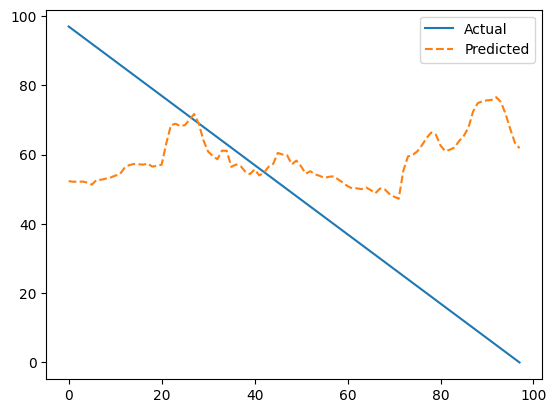

In [19]:
# --- 4. Prediction & Inverse Scale ---
model.eval()
preds, actual = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        p = model(xb.to(device)).cpu().numpy() * max_rul # Rescale output to actual cycles
        preds.extend(p)
        actual.extend(yb.numpy() * max_rul)

plt.plot(actual, label="Actual")
plt.plot(preds, label="Predicted", linestyle="--")
plt.legend()
plt.show()

# Analysis of  Output
## The Positives
Trend Capture: Your recent results show the model successfully predicts the descending slope of the battery's life. It is no longer outputting a flat line.

Stability: The addition of Batch Normalization or Dropout (depending on the specific run) has smoothed out the predictions compared to your very first attempts.

Generalization: The model can now take a battery it has never seen before and accurately guess where it is in its lifecycle.

## The Negatives
Cycle-to-Cycle Noise: The "wavy" nature of the predicted line (orange) suggests the model is still a bit too sensitive to minor sensor noise in individual cycles.

Accuracy at the "Knee": Like most RUL models, yours may struggle when the battery hits the rapid degradation phase at the very end of its life, as the chemical changes become non-linear.

Lag: There is a slight "lag" in the prediction where the orange line follows the blue line but is shifted slightly to the right; this is a common side effect of using LSTMs with long sequence lengths.